Install dependencies

In [1]:
pip install pennylane kagglehub torchvision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 99.5 MB/s eta 0:00:00


Imports and seeds

In [2]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import random
import zipfile
from PIL import Image
import numpy as np


SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


Hyperparameters

In [3]:
N_QUBITS = 8
N_LAYERS = 1
BATCH_SIZE = 32
N_EPOCHS = 30
LR = 0.001
N_TRAIN = 1000
N_TEST = 200
IMG_SIZE = 8

Quantum circuit and QCNN model

In [4]:
def block(weights, wires):
    qml.RY(weights[0], wires=wires[0])
    qml.RY(weights[1], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])

n_block_wires = 2
n_params_block = 2

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def qcnn_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.MERA(
        wires=range(N_QUBITS),
        n_block_wires=n_block_wires,
        block=block,
        n_params_block=n_params_block,
        template_weights=weights
    )
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

n_blocks = qml.MERA.get_n_blocks(range(N_QUBITS), n_block_wires)
weight_shapes = {"weights": (n_blocks, n_params_block)}

class PiScaledTanh(nn.Module):
    def forward(self, x):
        return torch.tanh(x) * 3.14159265

class QCNNClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.reduction = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMG_SIZE * IMG_SIZE, 64),
            nn.ReLU(),
            nn.Linear(64, N_QUBITS),
            PiScaledTanh()
            )
        self.qlayer = qml.qnn.TorchLayer(qcnn_circuit, weight_shapes)
        self.fc = nn.Linear(N_QUBITS, n_classes)

    def forward(self, x):
        x = self.reduction(x)
        x = self.qlayer(x.cpu())
        x = self.fc(x.to(device))
        return x

Helper functions

In [5]:
def add_gaussian_noise(data, noise_std):
    noisy = []
    for img, label in data:
        if noise_std > 0:
            img = torch.clamp(img + torch.randn_like(img) * noise_std, -1.0, 1.0)
        noisy.append((img, label))
    return noisy

def collate_fn(batch):
    imgs, labels = zip(*batch)
    return torch.stack(imgs), torch.tensor(labels)

def get_subset(dataset, n_samples, n_classes):
    indices = []
    class_counts = {i: 0 for i in range(n_classes)}
    per_class = n_samples // n_classes
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label = int(label)
        if label < n_classes and class_counts[label] < per_class:
            indices.append(idx)
            class_counts[label] += 1
        if sum(class_counts.values()) >= n_samples:
            break
    return indices

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

def run_experiment(train_data, test_data, n_classes, dataset_name, noise_label):
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    model = QCNNClassifier(n_classes=n_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, train_accs, test_accs = [], [], [], []
    for epoch in range(N_EPOCHS):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = eval_epoch(model, test_loader, criterion)
        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)
        if (epoch + 1) % 5 == 0:
            print(f"[{dataset_name} | Noise={noise_label}] Epoch {epoch+1}/{N_EPOCHS} | "
                  f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
                  f"Test Loss: {te_loss:.4f} Acc: {te_acc:.4f}")
    return {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "final_test_acc": test_accs[-1]
    }

Loading MNIST and FMNIST

In [6]:
mnist_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train_full = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test_full  = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

mnist_train_raw = [mnist_train_full[i] for i in get_subset(mnist_train_full, N_TRAIN, 10)]
mnist_test_raw  = [mnist_test_full[i]  for i in get_subset(mnist_test_full,  N_TEST,  10)]

fmnist_train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=mnist_transform)
fmnist_test_full  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=mnist_transform)

fmnist_train_raw = [fmnist_train_full[i] for i in get_subset(fmnist_train_full, N_TRAIN, 10)]
fmnist_test_raw  = [fmnist_test_full[i]  for i in get_subset(fmnist_test_full,  N_TEST,  10)]

print(f"MNIST  — Train: {len(mnist_train_raw)}, Test: {len(mnist_test_raw)}")
print(f"F-MNIST — Train: {len(fmnist_train_raw)}, Test: {len(fmnist_test_raw)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]
100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.5MB/s]


MNIST  — Train: 1000, Test: 200
F-MNIST — Train: 1000, Test: 200


Loading Brain Tumour dataset from Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/brain_tumour_dataset.zip"
extract_path = "/content/brain_tumour_dataset"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Extracted contents:")
for entry in os.listdir(extract_path):
    print(" ", entry)

Mounted at /content/drive
Extracted contents:
  Testing
  Training


Brain Tumour dataset class and loading

In [8]:
brain_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        for idx, cls in enumerate(classes):
            self.class_to_idx[cls] = idx
            for fname in os.listdir(os.path.join(root_dir, cls)):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(root_dir, cls, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

brain_train_dir = os.path.join(extract_path, "Training")
brain_test_dir  = os.path.join(extract_path, "Testing")

brain_train_full = BrainTumorDataset(brain_train_dir, transform=brain_transform)
brain_test_full  = BrainTumorDataset(brain_test_dir,  transform=brain_transform)

N_BRAIN_CLASSES = len(brain_train_full.class_to_idx)
print(f"Brain tumour classes ({N_BRAIN_CLASSES}): {brain_train_full.class_to_idx}")

brain_train_raw = [brain_train_full[i] for i in get_subset(brain_train_full, N_TRAIN, N_BRAIN_CLASSES)]
brain_test_raw  = [brain_test_full[i]  for i in get_subset(brain_test_full,  N_TEST,  N_BRAIN_CLASSES)]

print(f"Brain Tumour — Train: {len(brain_train_raw)}, Test: {len(brain_test_raw)}")

Brain tumour classes (4): {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Brain Tumour — Train: 1000, Test: 200


Run all experiments

In [9]:
NOISE_LEVELS = [0.0, 0.05, 0.10]
results = {}

for noise_std in NOISE_LEVELS:
    noise_label = f"{int(noise_std * 100)}%"

    print(f"\n{'='*60}")
    print(f"Running QCNN on MNIST with {noise_label} Gaussian noise")
    results[f"MNIST_{noise_label}"] = run_experiment(
        add_gaussian_noise(mnist_train_raw, noise_std),
        add_gaussian_noise(mnist_test_raw,  noise_std),
        10, "MNIST", noise_label
    )

    print(f"\n{'='*60}")
    print(f"Running QCNN on F-MNIST with {noise_label} Gaussian noise")
    results[f"FMNIST_{noise_label}"] = run_experiment(
        add_gaussian_noise(fmnist_train_raw, noise_std),
        add_gaussian_noise(fmnist_test_raw,  noise_std),
        10, "F-MNIST", noise_label
    )

    print(f"\n{'='*60}")
    print(f"Running QCNN on Brain Tumour with {noise_label} Gaussian noise")
    results[f"BrainTumor_{noise_label}"] = run_experiment(
        add_gaussian_noise(brain_train_raw, noise_std),
        add_gaussian_noise(brain_test_raw,  noise_std),
        N_BRAIN_CLASSES, "BrainTumor", noise_label
    )


Running QCNN on MNIST with 0% Gaussian noise
[MNIST | Noise=0%] Epoch 5/30 | Train Loss: 1.8009 Acc: 0.4540 | Test Loss: 1.7716 Acc: 0.4450
[MNIST | Noise=0%] Epoch 10/30 | Train Loss: 1.4716 Acc: 0.5250 | Test Loss: 1.4939 Acc: 0.5050
[MNIST | Noise=0%] Epoch 15/30 | Train Loss: 1.2864 Acc: 0.5710 | Test Loss: 1.3277 Acc: 0.5500
[MNIST | Noise=0%] Epoch 20/30 | Train Loss: 1.1351 Acc: 0.6290 | Test Loss: 1.2089 Acc: 0.5650
[MNIST | Noise=0%] Epoch 25/30 | Train Loss: 0.9768 Acc: 0.7180 | Test Loss: 1.1071 Acc: 0.6800
[MNIST | Noise=0%] Epoch 30/30 | Train Loss: 0.8431 Acc: 0.7960 | Test Loss: 0.9326 Acc: 0.7450

Running QCNN on F-MNIST with 0% Gaussian noise
[F-MNIST | Noise=0%] Epoch 5/30 | Train Loss: 1.5395 Acc: 0.5530 | Test Loss: 1.4941 Acc: 0.6050
[F-MNIST | Noise=0%] Epoch 10/30 | Train Loss: 1.1772 Acc: 0.7360 | Test Loss: 1.1534 Acc: 0.7300
[F-MNIST | Noise=0%] Epoch 15/30 | Train Loss: 0.9624 Acc: 0.7730 | Test Loss: 0.9632 Acc: 0.7450
[F-MNIST | Noise=0%] Epoch 20/30 | Tra

Print accuracy summary

In [10]:
print("\n" + "="*55)
print(f"{'Dataset + Noise':<30} {'Final Test Accuracy':>20}")
print("="*55)
for key, val in results.items():
    print(f"{key:<30} {val['final_test_acc']*100:>19.2f}%")
print("="*55)


Dataset + Noise                 Final Test Accuracy
MNIST_0%                                     74.50%
FMNIST_0%                                    78.00%
BrainTumor_0%                                60.50%
MNIST_5%                                     75.00%
FMNIST_5%                                    76.50%
BrainTumor_5%                                60.50%
MNIST_10%                                    69.50%
FMNIST_10%                                   74.50%
BrainTumor_10%                               61.00%


Plot loss curves

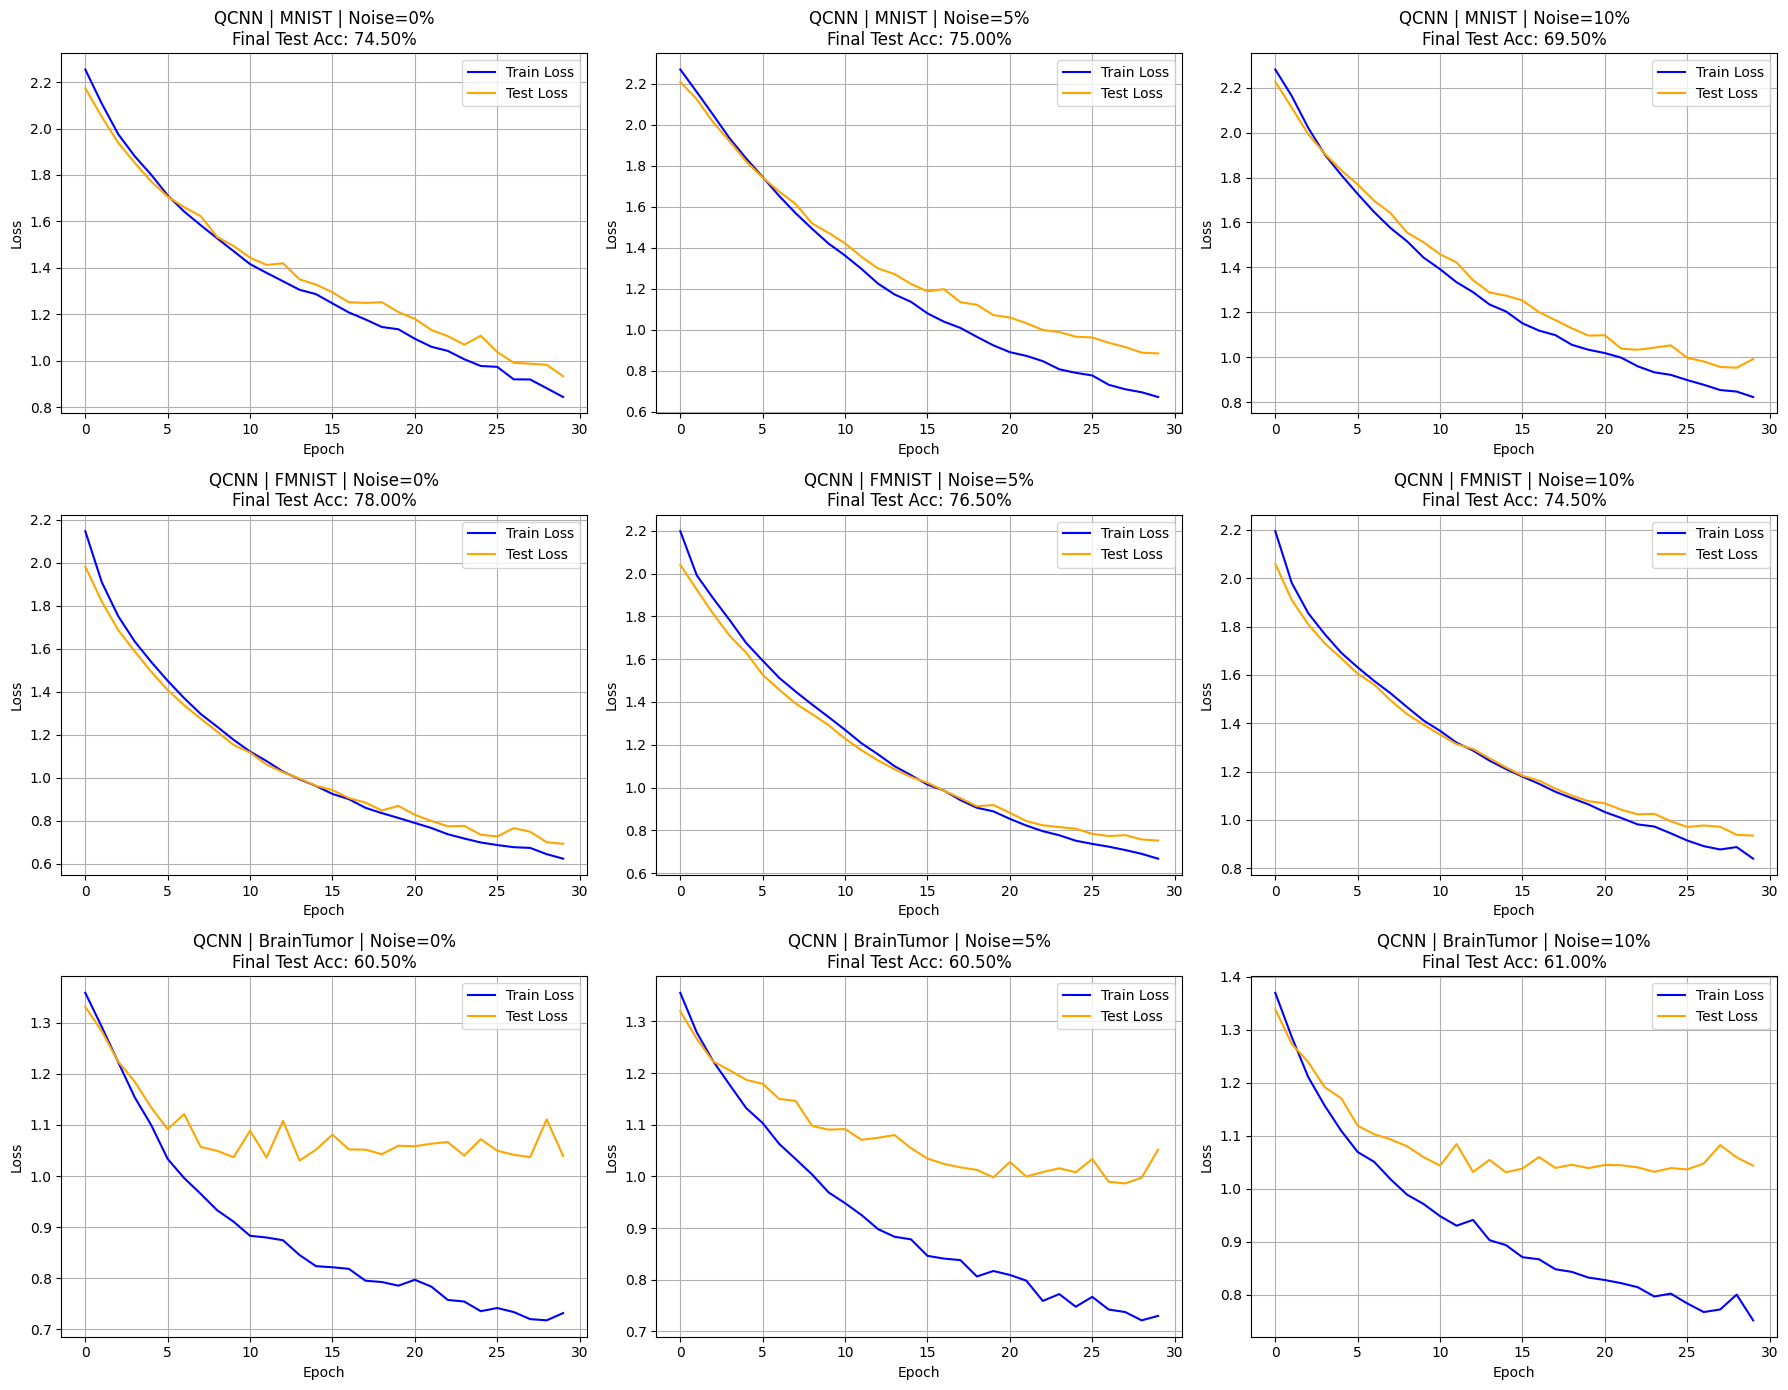

In [11]:
dataset_names = ["MNIST", "FMNIST", "BrainTumor"]
noise_labels  = ["0%", "5%", "10%"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for row, ds in enumerate(dataset_names):
    for col, nl in enumerate(noise_labels):
        key = f"{ds}_{nl}"
        ax = axes[row][col]
        ax.plot(results[key]["train_losses"], label="Train Loss", color="blue")
        ax.plot(results[key]["test_losses"],  label="Test Loss",  color="orange")
        ax.set_title(f"QCNN | {ds} | Noise={nl}\nFinal Test Acc: {results[key]['final_test_acc']*100:.2f}%")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)
plt.tight_layout()
plt.savefig("qcnn_loss_curves.png", dpi=150)
plt.show()

Plot accuracy bar charts

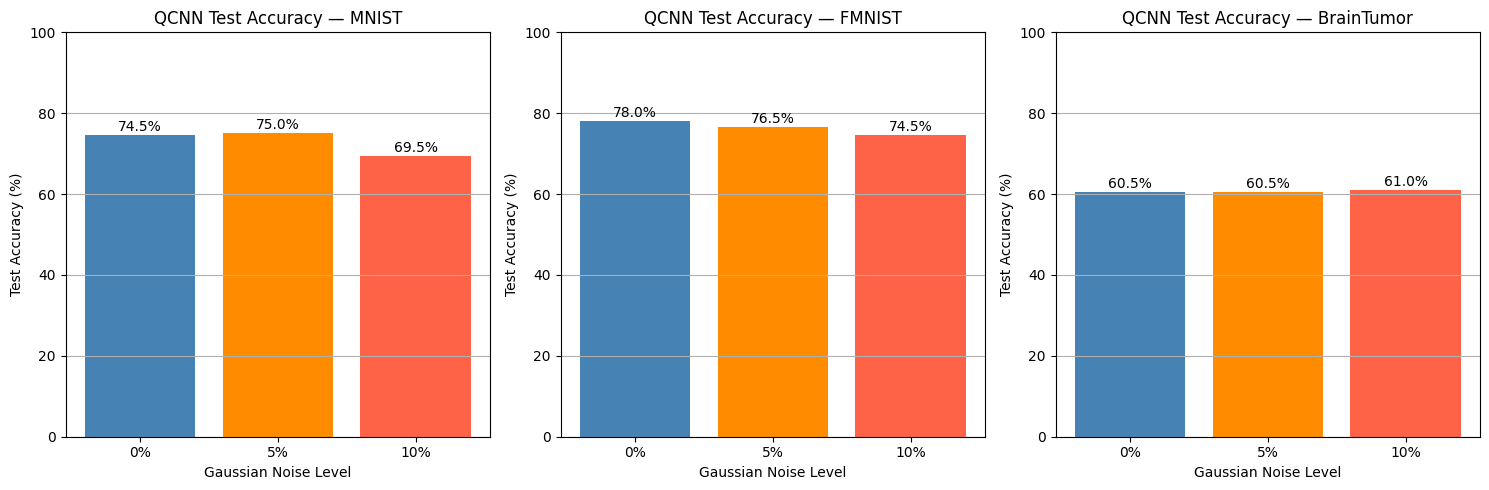

In [12]:
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
for col, ds in enumerate(dataset_names):
    accs = [results[f"{ds}_{nl}"]["final_test_acc"] * 100 for nl in noise_labels]
    axes2[col].bar(noise_labels, accs, color=["steelblue", "darkorange", "tomato"])
    axes2[col].set_title(f"QCNN Test Accuracy — {ds}")
    axes2[col].set_xlabel("Gaussian Noise Level")
    axes2[col].set_ylabel("Test Accuracy (%)")
    axes2[col].set_ylim(0, 100)
    for i, v in enumerate(accs):
        axes2[col].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
    axes2[col].grid(axis="y")
plt.tight_layout()
plt.savefig("qcnn_accuracy_bars.png", dpi=150)
plt.show()